Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.800/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.800/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/cavitation_initial.gsd


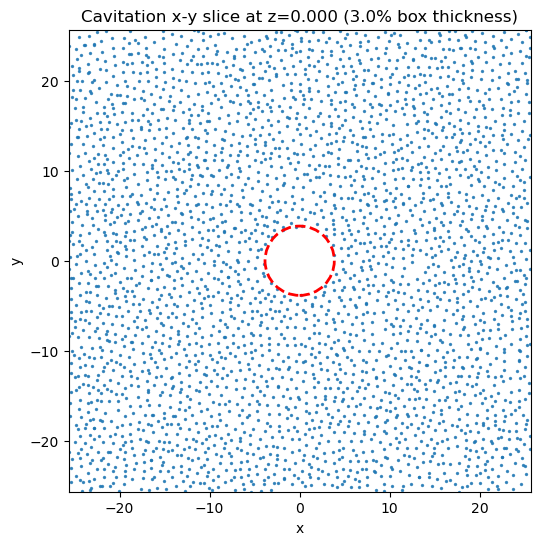

In [1]:
from md_Helpers import cavitation as cav
from md_Helpers import runs, visualization as vh


initial = cav.get_or_create_cavitation_state(
    n_fcc_cells=30,
    target_rho=0.800,
    kT=0.800,
    source_nsteps=1_000_000,
    source_seed=1,
    source_phase_name="randomization",

    radius_fraction=0.15,
    random_location=False,
    bubble_seed=1,

    require_existing_source=True,
    overwrite=False,
)

initial["paths"]
initial["creation_info"]

import importlib
from md_Helpers import visualization as vh
importlib.reload(vh)

vh.plot_cavitation_xy_slice(
    initial,
    fraction=0.03,
    point_size=2,
    alpha=0.8,
    show_bubble=True,
)

In [2]:
import importlib
from md_Helpers import cavitation as cav
from md_Helpers import runs

importlib.reload(runs)
importlib.reload(cav)

evolution = cav.get_or_create_cavitation(
    n_fcc_cells=30,
    target_rho=0.71,
    kT=0.80,
    source_nsteps=1_000_000,
    radius_fraction=0.15,
    evolve_nsteps=100_000,
)

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_30/rho_0.710/kT_0.800/nsteps_1000000/seed_1/randomization.gsd
Loaded existing cavitation initial state:
/exp/e961/data/MDsims-data/pnichols/Cavitation_States_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/cavitation_initial.gsd
Loaded existing cavitation evolution:
/exp/e961/data/MDsims-data/pnichols/Cavitation_Evolved_v3/FCC/n_cells_30/source_rho_0.710/kT_0.800/source_nsteps_1000000/source_seed_1/source_phase_randomization/radius_fraction_0.150/center_box/evolve_kT_0.800/nsteps_100000/seed_1/cavitation_final.gsd


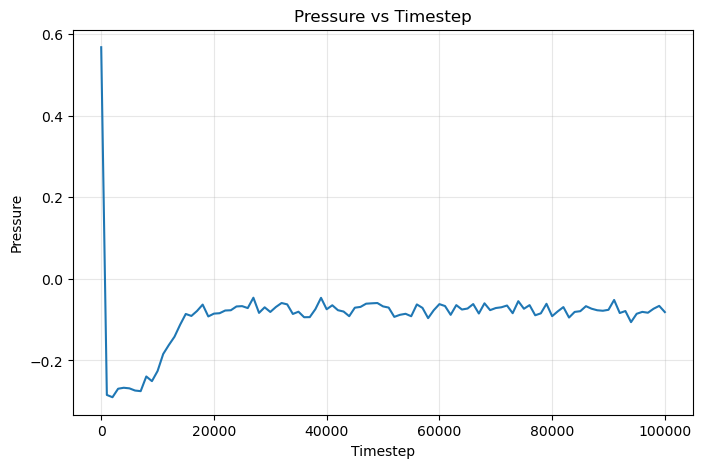

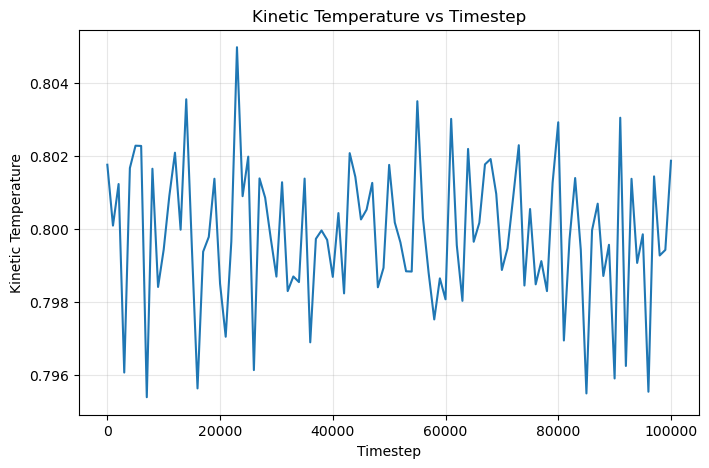

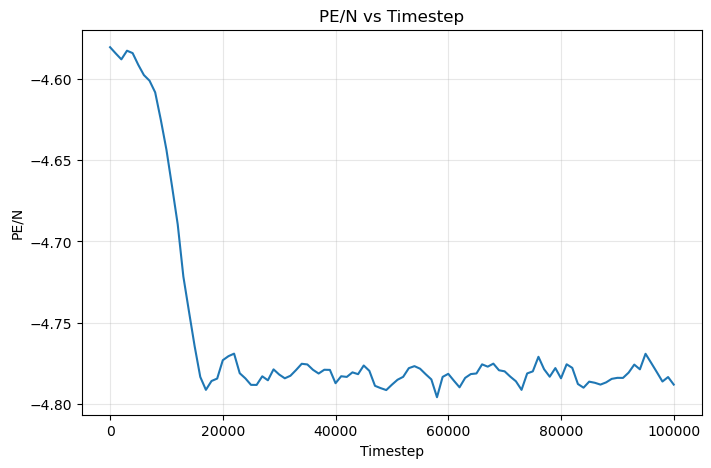

In [3]:
log_path = evolution["paths"]["log_path"]
log = runs.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_temperature")
vh.plot_log_quantity(log, "potential_energy")

In [4]:
from md_Helpers import visualization as vh

trajectory_path = evolution["paths"]["trajectory_path"]
center_z = evolution["initial_result"]["creation_info"].get("bubble_center_z", 0.0)

vh.animate_xy_slice_trajectory(
    trajectory_path,
    fraction=0.03,
    max_frames=100,
    interval=120,
)

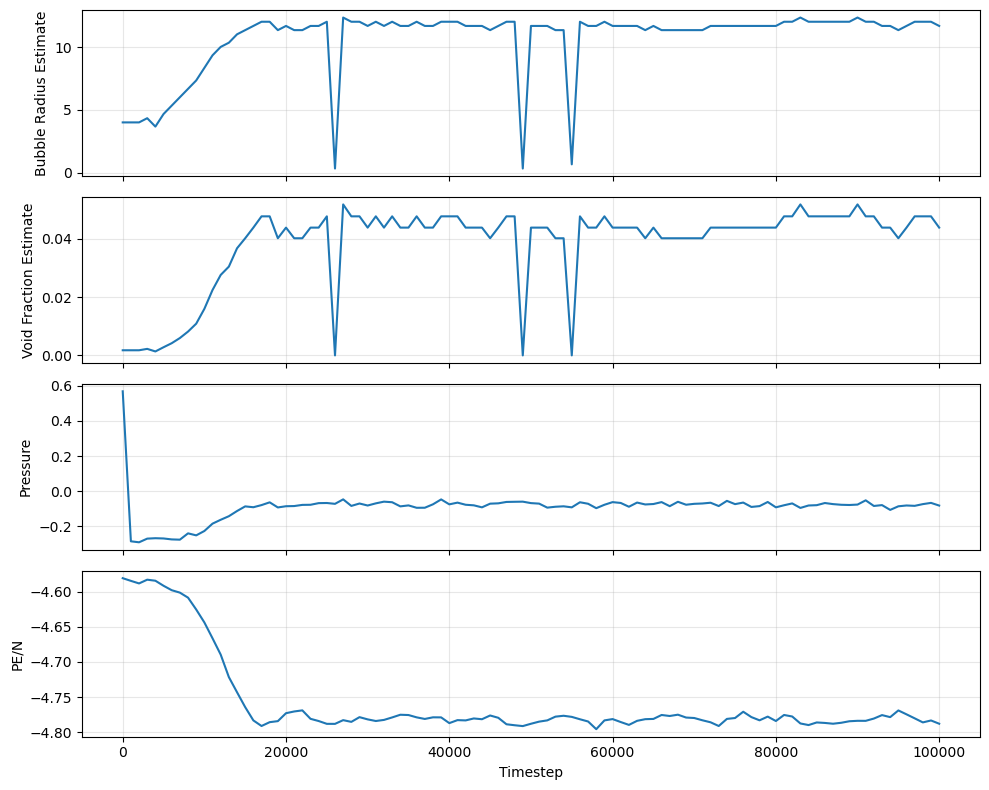

In [7]:
import importlib
from md_Helpers import cavitation as cav
from md_Helpers import visualization as vh

importlib.reload(cav)
importlib.reload(vh)

measurements = cav.measure_cavitation_trajectory(
    evolution,
    n_radial_bins=80,
    density_threshold_fraction=0.5,
    save_csv_path=evolution["paths"]["folder"] / "cavitation_measurements.csv",
)
vh.plot_cavitation_measurements(measurements)